In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### 数据读取

In [2]:
df = pd.read_csv('data.csv', sep=';', quotechar='"', encoding='utf-8')

columns_to_drop = ['Po', 'DD', 'ff10', 'ff3', 'N', 'WW', 'W1', 'W2', 'Cl', 'Nh', 'H', 'Cm', 'Ch', 'RRR', 
                   'E', 'Tg', 'Ee', 'sss', 'unused', '当地时间 杭州市(机场)', 'tR', 'Pa']
df["时间"] = pd.to_datetime(
    df["当地时间 杭州市(机场)"],
    format="%d.%m.%Y %H:%M"
)
df = df.drop(columns=columns_to_drop, errors='ignore')
df = df.sort_values('时间').reset_index(drop=True)
print(df.head(2).to_markdown(index = False))
df = df.set_index('时间')

|    T |     P |   U |   Ff |   Tn |   Tx |   VV |   Td | 时间                |
|-----:|------:|----:|-----:|-----:|-----:|-----:|-----:|:--------------------|
| 25.2 | 751.5 |  79 |    1 |  nan |   33 |    6 | 21.3 | 2005-06-03 02:00:00 |
| 27.7 | 753   |  70 |    1 |  nan |  nan |    4 | 21.7 | 2005-06-03 08:00:00 |


### 补充缺失值

In [3]:
missing_summary = df.isna().mean().sort_values(ascending=False)

print(missing_summary.apply(lambda x: f"{x:.2%}"))

Tx    58.51%
Tn    55.68%
VV     3.00%
P      0.50%
Ff     0.02%
U      0.01%
T      0.01%
Td     0.01%
dtype: object


In [4]:
df = df.sort_values('时间')
features = ['Tx','Tn', 'VV', 'P', 'Ff', 'U', 'Td', 'T']
df[features] = df[features].fillna(method='bfill')
df[features] = df[features].fillna(method='ffill')

In [5]:
null_rows_count = df.isna().any(axis=1).sum()
print(f"包含空数据的行数: {null_rows_count}")

包含空数据的行数: 0


In [6]:
missing_summary = df.isna().mean().sort_values(ascending=False)
print(missing_summary.apply(lambda x: f"{x:.2%}"))

T     0.00%
P     0.00%
U     0.00%
Ff    0.00%
Tn    0.00%
Tx    0.00%
VV    0.00%
Td    0.00%
dtype: object


In [7]:
print(df.dtypes)

T     float64
P     float64
U     float64
Ff    float64
Tn    float64
Tx    float64
VV     object
Td    float64
dtype: object


In [8]:
df['VV']=df['VV'].replace('低于 0.1', 0.0)
df['VV']=df['VV'].astype('float64')

In [9]:
print(type(df.index))
print(df.index)

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
DatetimeIndex(['2005-06-03 02:00:00', '2005-06-03 08:00:00',
               '2005-06-03 14:00:00', '2005-06-03 20:00:00',
               '2005-06-04 02:00:00', '2005-06-04 08:00:00',
               '2005-06-04 14:00:00', '2005-06-04 20:00:00',
               '2005-06-05 02:00:00', '2005-06-05 08:00:00',
               ...
               '2025-06-01 23:00:00', '2025-06-02 02:00:00',
               '2025-06-02 05:00:00', '2025-06-02 08:00:00',
               '2025-06-02 11:00:00', '2025-06-02 14:00:00',
               '2025-06-02 17:00:00', '2025-06-02 20:00:00',
               '2025-06-02 23:00:00', '2025-06-03 02:00:00'],
              dtype='datetime64[ns]', name='时间', length=47354, freq=None)


In [10]:
first_time = df.index[0]

resampled = df.resample(
    '6H',
    origin=first_time,
    closed='left' 
).agg({
    'T': 'mean',
    'P': 'mean',
    'U': 'mean',
    'Ff': 'mean',
    'Tn': 'min',   
    'Tx': 'max',   
    'VV': 'mean',
    'Td': 'mean'
})

null_rows = resampled.isna().any(axis=1)

for col in resampled.columns:
    interpolated = resampled[col].interpolate(method='time')
    
    resampled.loc[null_rows, col] = interpolated.loc[null_rows]

df = resampled

### 数据可视化

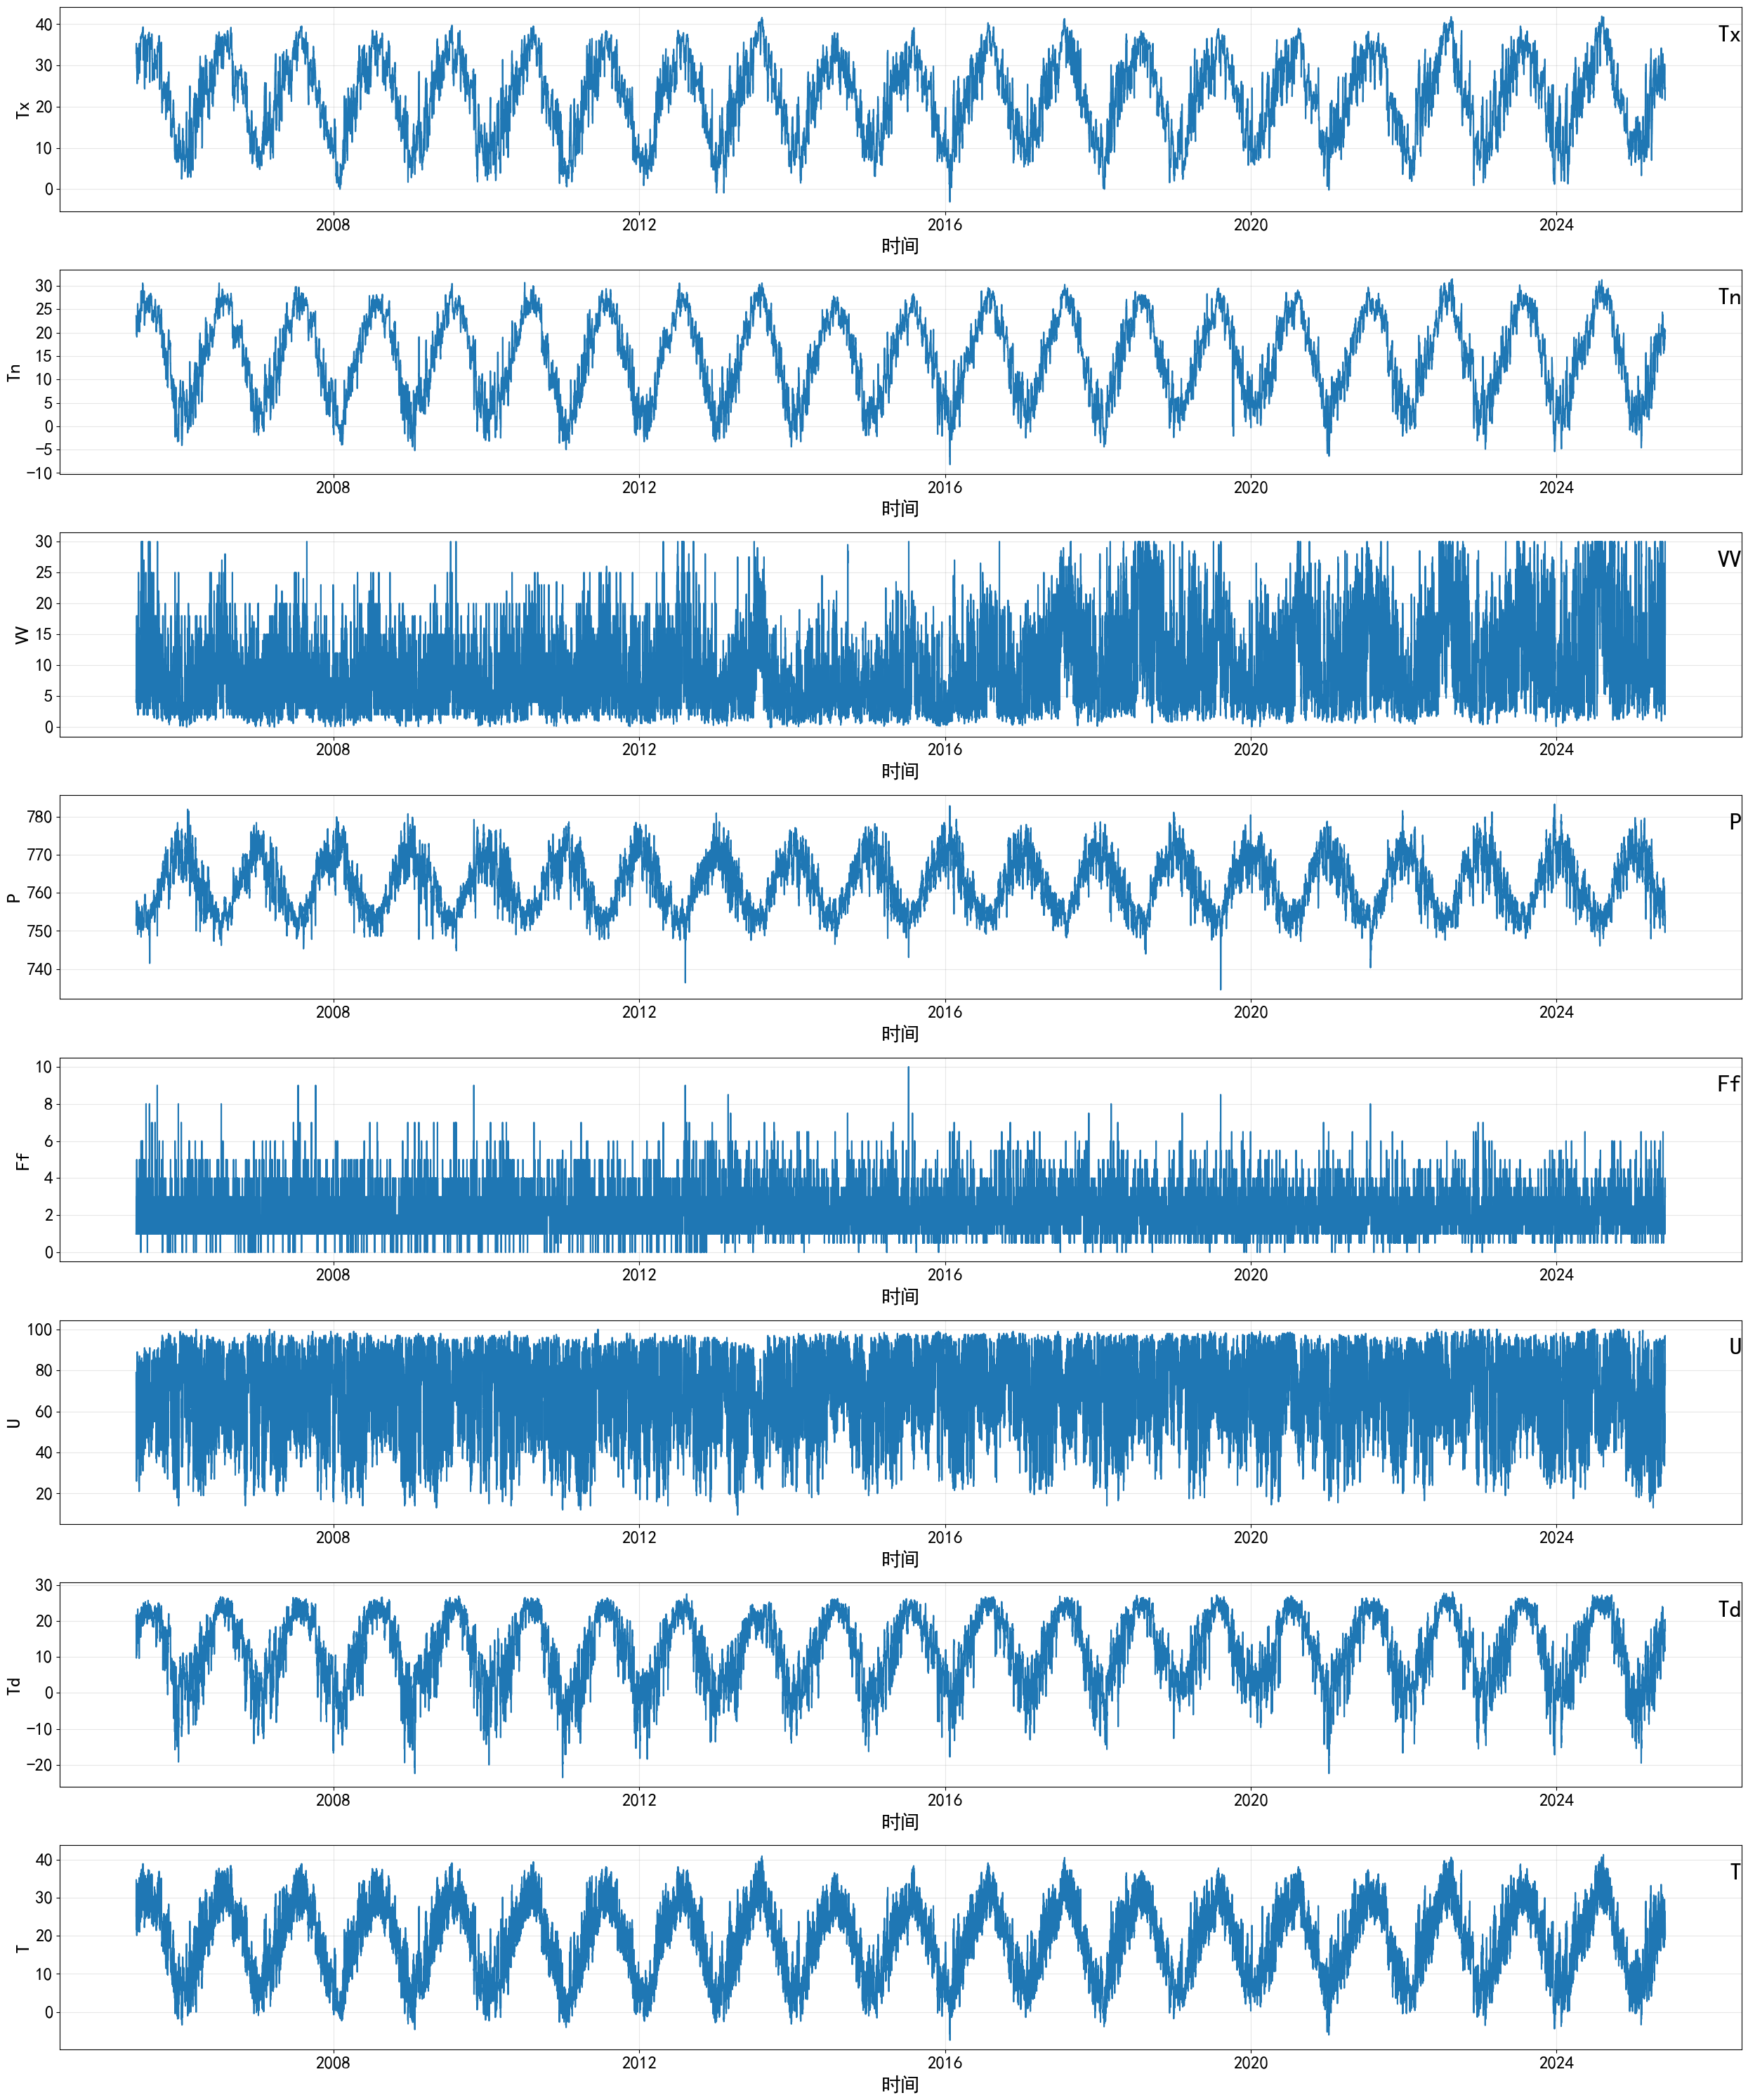

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(25, 30))

for i, col in enumerate(features, 1):
    plt.subplot(len(features), 1, i)
    plt.plot(df.index, df[col], linewidth=1.5)
    plt.title(col, y=0.8, loc='right', fontsize=25)
    plt.xlabel('时间', fontsize=20)
    plt.ylabel(col, fontsize=20)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

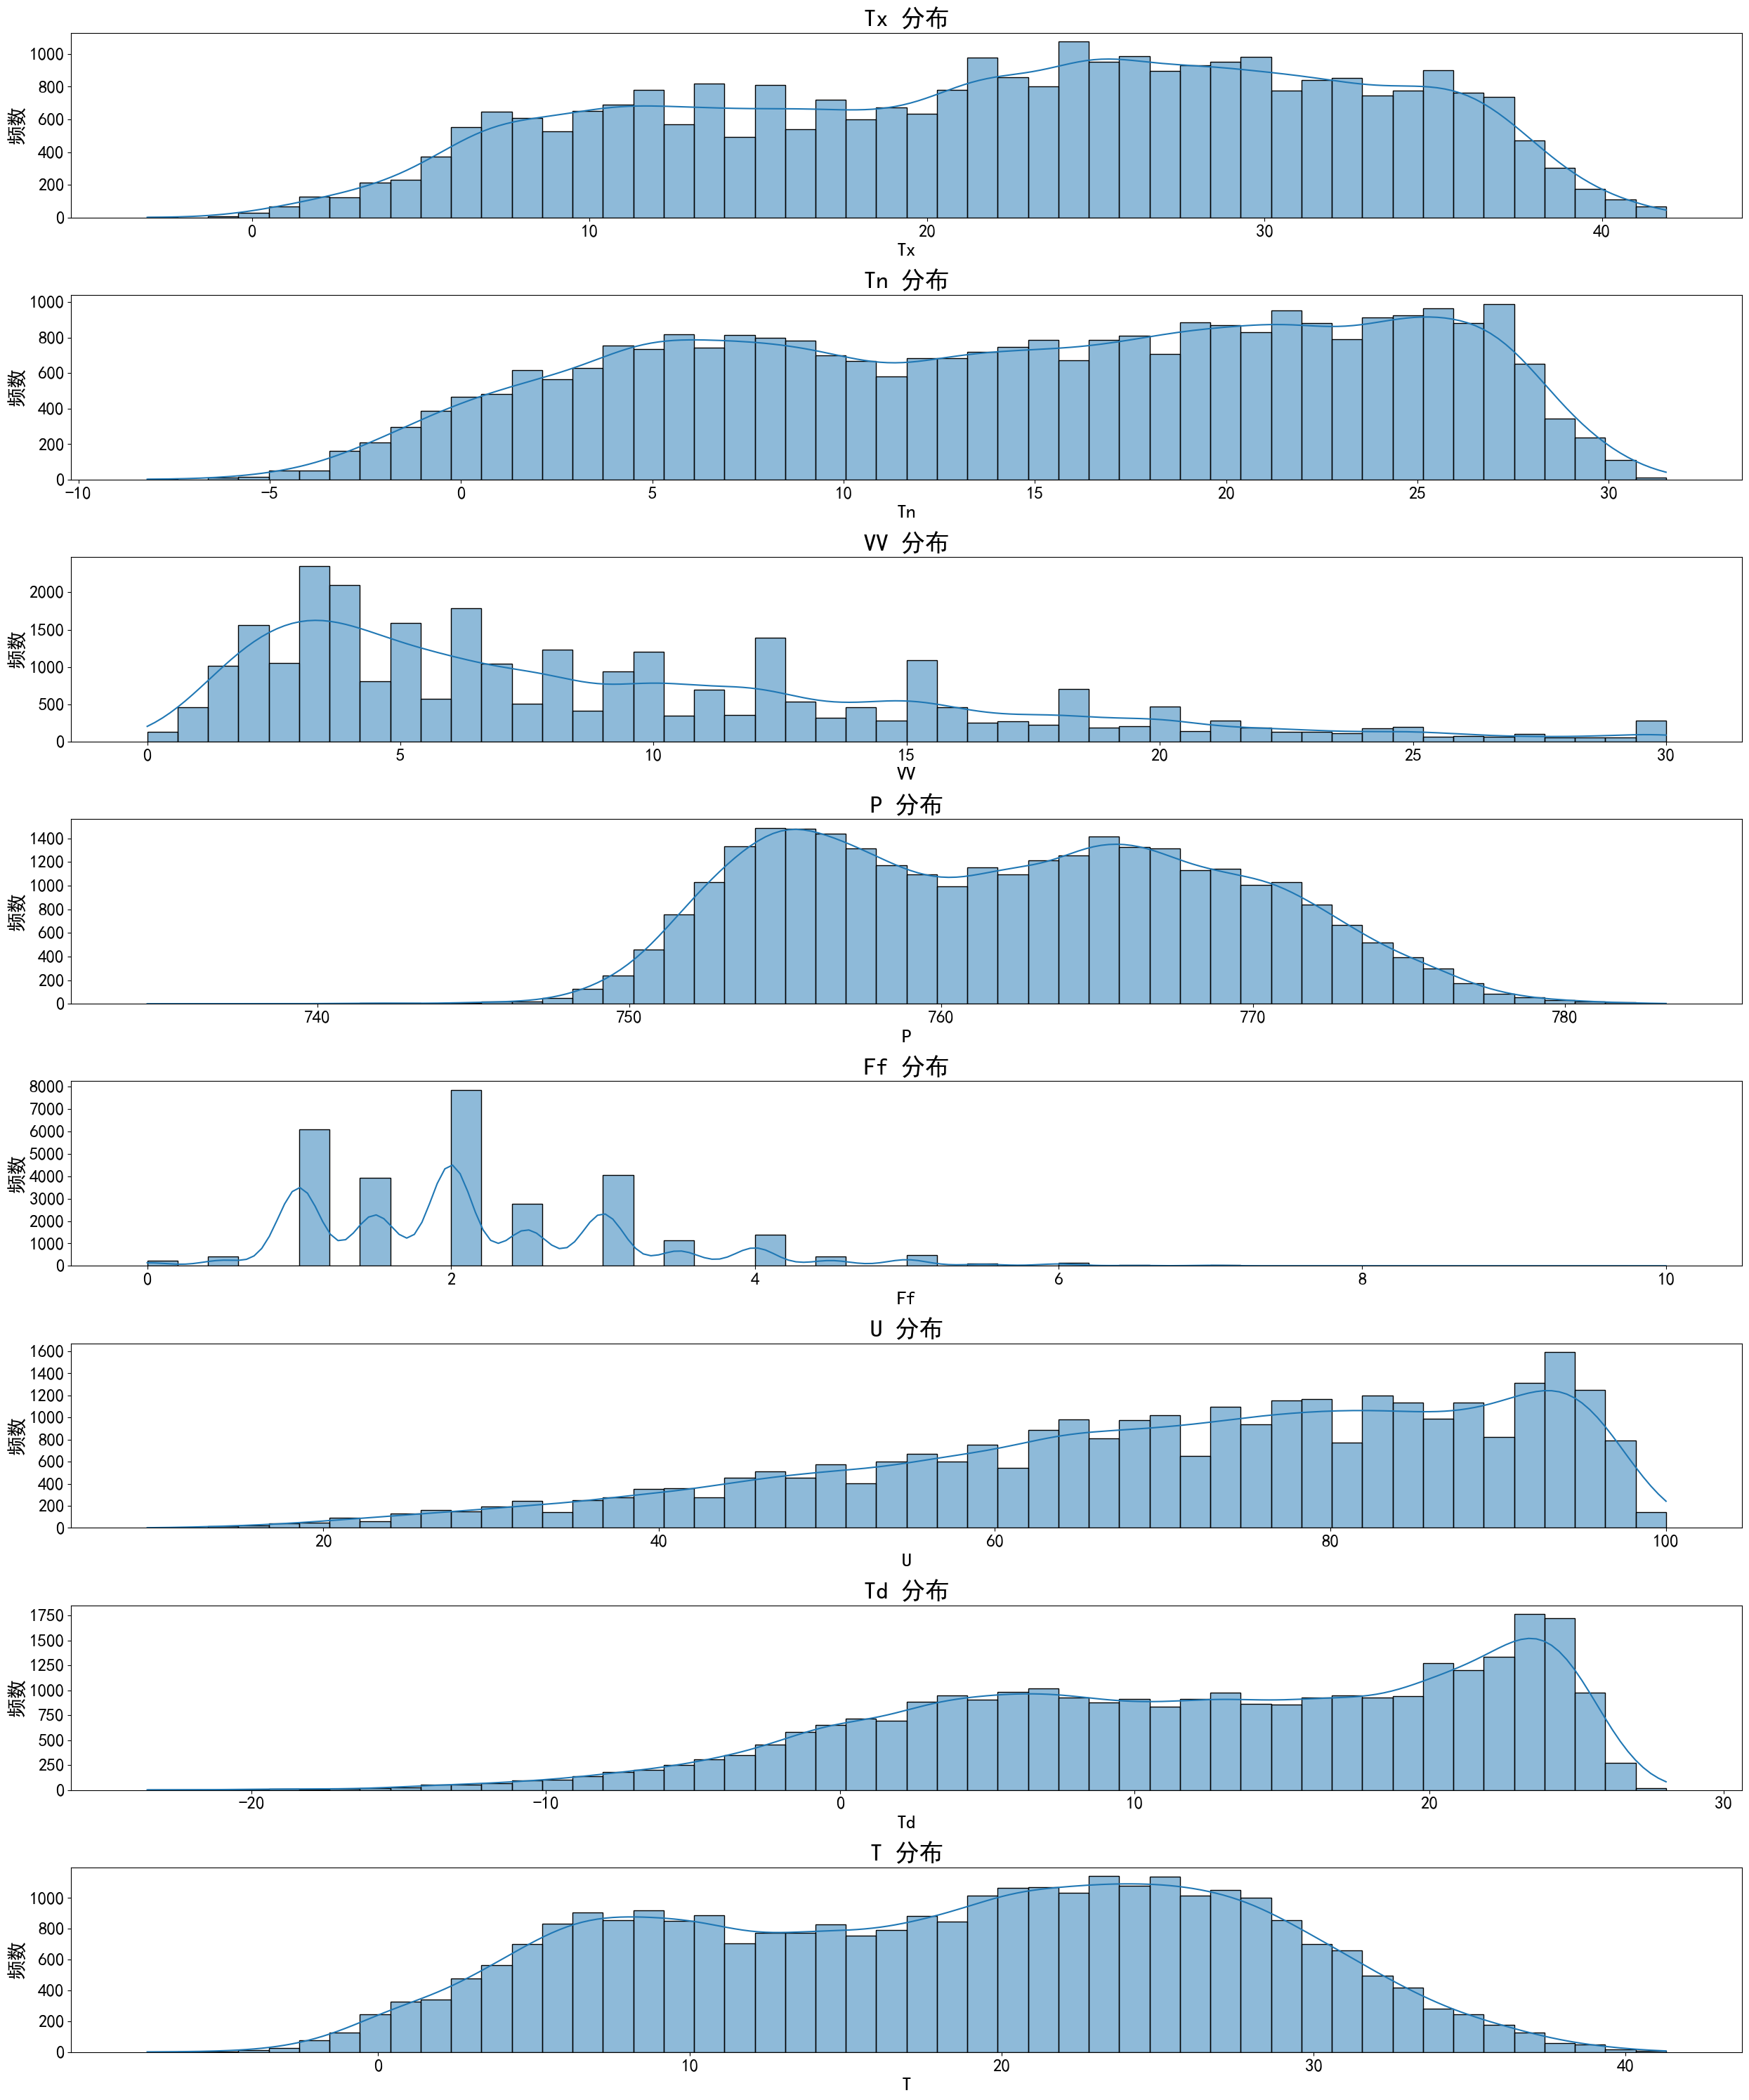

In [12]:
plt.figure(figsize=(25, 30))

for i, col in enumerate(features, 1):
    plt.subplot(len(features), 1, i)
    sns.histplot(df[col], bins=50, kde=True, edgecolor='black')
    plt.title(f'{col} 分布', fontsize=25)
    plt.xlabel(col, fontsize=20)
    plt.ylabel('频数', fontsize=20)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)

plt.tight_layout()
plt.show()

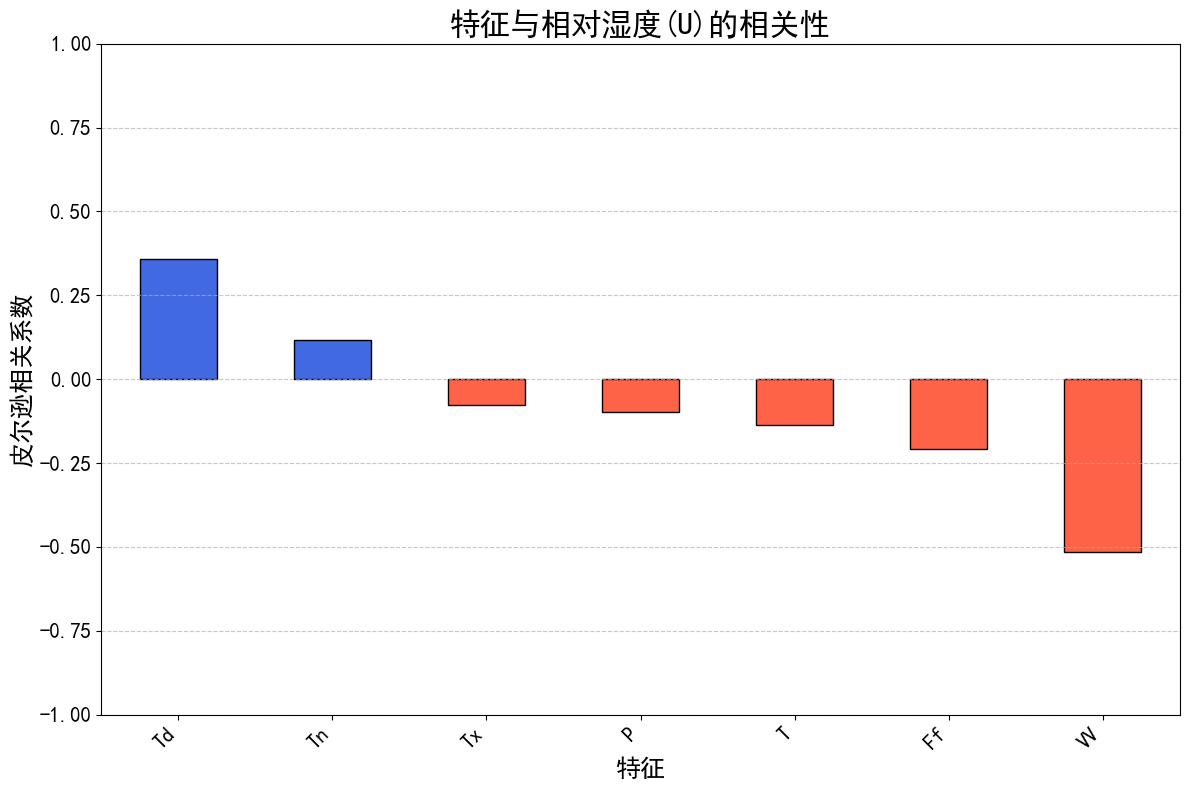

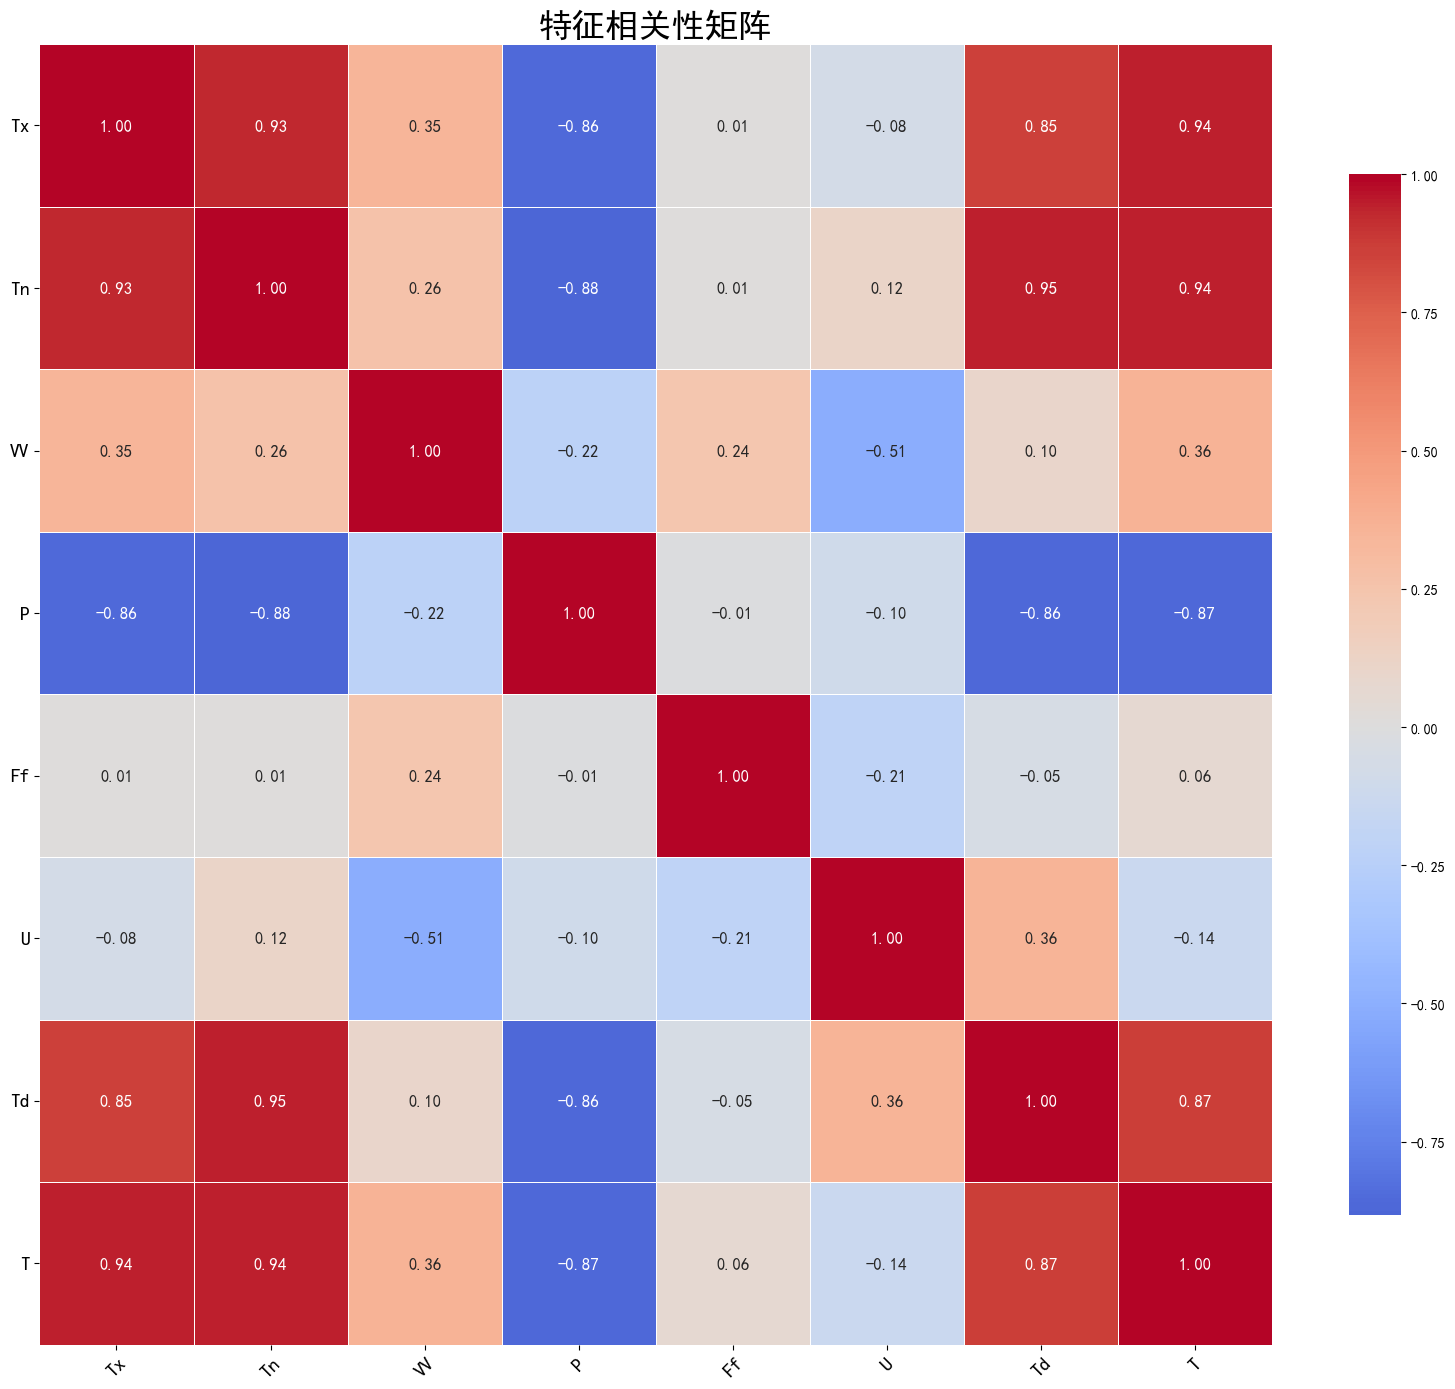

In [13]:
corr_matrix = df[features].corr()

plt.figure(figsize=(12, 8))
corr_with_U = corr_matrix['U'].sort_values(ascending=False).drop('U')
corr_with_U.plot(kind='bar', 
                color=np.where(corr_with_U >= 0, 'royalblue', 'tomato'),
                edgecolor='black')
plt.title('特征与相对湿度(U)的相关性', fontsize=22)
plt.xlabel('特征', fontsize=18)
plt.ylabel('皮尔逊相关系数', fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=15)
plt.yticks(fontsize=15)
plt.ylim(-1, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, 
           annot=True, 
           fmt=".2f",
           cmap='coolwarm',
           center=0,
           linewidths=0.5,
           annot_kws={'size': 12},
           cbar_kws={'shrink': 0.8})
plt.title('特征相关性矩阵', fontsize=24)
plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14, rotation=0)
plt.tight_layout()
plt.show()

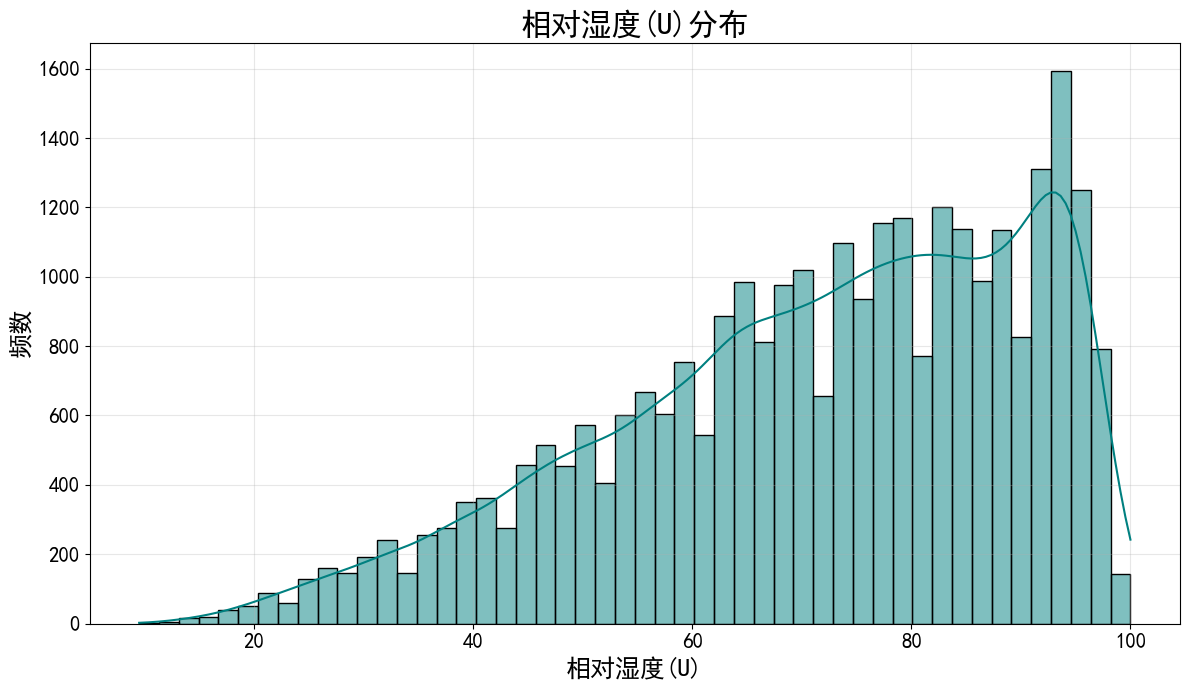

In [14]:
plt.figure(figsize=(12, 7))
sns.histplot(df['U'], bins=50, kde=True, color='teal', edgecolor='black')
plt.title('相对湿度(U)分布', fontsize=22)
plt.xlabel('相对湿度(U)', fontsize=18)
plt.ylabel('频数', fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 预处理数据存储

In [15]:
df.to_csv('preprocessed_data.csv', index=False, encoding='utf-8-sig')